EDA (IMDB Dataset)

In [243]:
import pandas as pd
import numpy as np

Loading the dataset

In [244]:
df = pd.read_csv("IMDB.csv")

Shape of the dataset

In [245]:
df.shape

(50000, 2)

Top 5 elements

In [246]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


Checking for Null Values

In [248]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

Checking for Duplicate Values

In [249]:
df.duplicated().value_counts()

False    49582
True       418
Name: count, dtype: int64

In [250]:
df.drop_duplicates(inplace=True)

Sentiment Distribution

In [251]:
df["sentiment"].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [252]:
import html
import re
def clean_text(text: str) -> str:
    text = html.unescape(text) # converts html escape sequences into actual characters
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE) # removes html br tags
    text = re.sub(r"<[^>]+>", " ", text) # removes all remaining html tags
    return re.sub(r"\s+", " ", text).strip() # replaces multiple white spaces with single white space and removes preceeding and trailing white spaces

Applying the Cleanup function to the dataset

In [253]:
df["review"] = df["review"].apply(clean_text)

Cleaned up data

In [254]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [255]:
df["char_count"] = df["review"].str.len() # character count of each review
df["word_count"] = df["review"].apply(lambda x: len(x.split())) # word count of each review
df["sentence_count"] = df["review"].apply(lambda x: len(x.split("."))) # sentence count

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

Histogram plotting word count distribution in Reviews

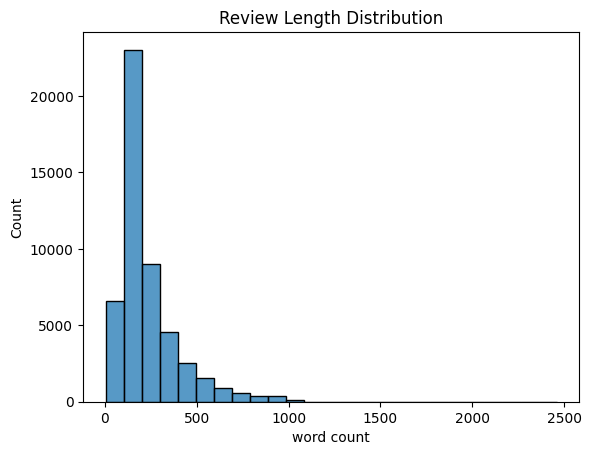

In [257]:

sns.histplot(df['word_count'], bins=25)
plt.title("Review Length Distribution")
plt.xlabel("word count")

plt.show()

Boxplot for finding the relation between Word Count and Sentiment

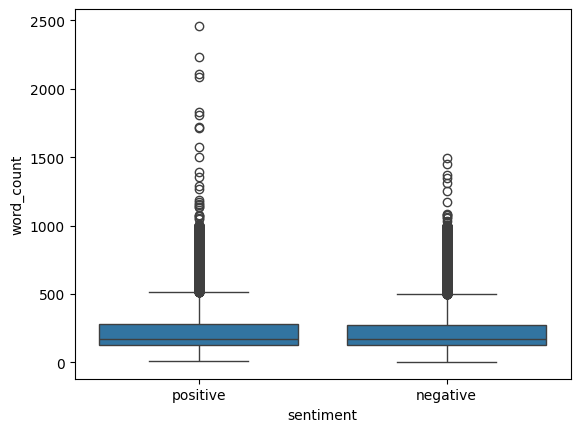

In [258]:
sns.boxplot(
    x='sentiment',
    y='word_count',
    data=df
)
plt.show()

Plotting the most common words

In [259]:
from collections import Counter

all_words = " ".join(df['review']).lower().split()

common_words = Counter(all_words).most_common(20)

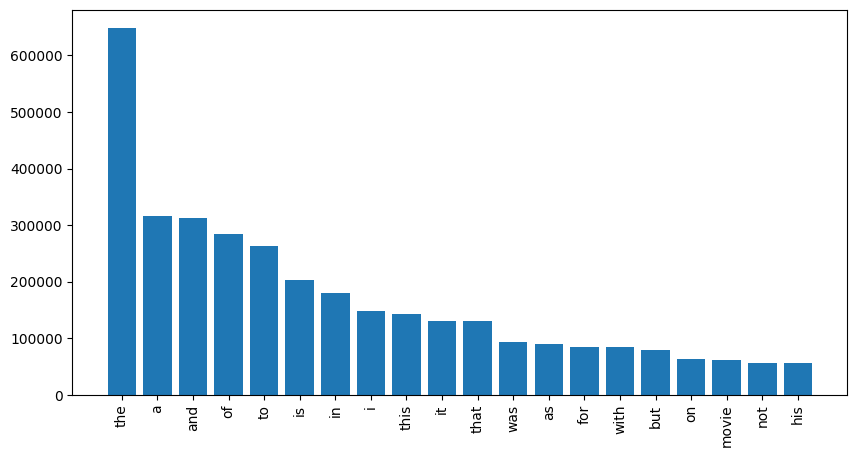

In [260]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

Label Encoding "review" Column

In [265]:
le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])

In [268]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Splitting the features and labels for a sample model from the dataset

In [269]:
X = df["review"]
y = df["sentiment"]
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

Defining Pipeline

In [270]:
pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(C=1.0, max_iter=1000)),
    ])

In [271]:
model = pipe.fit(xtrain, ytrain)

In [272]:
ypred = model.predict(xtest)

In [279]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7404
           1       0.89      0.91      0.90      7471

    accuracy                           0.90     14875
   macro avg       0.90      0.90      0.90     14875
weighted avg       0.90      0.90      0.90     14875

